In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import  matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("thyroid_dataset.csv")

In [3]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [4]:
X=df.drop("Outlier_label",axis=1)
y=df["Outlier_label"]

In [5]:
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [6]:
from sklearn.ensemble import IsolationForest

isf=IsolationForest(n_estimators=200,contamination='auto',random_state=42)
labels=isf.fit_predict(X_scaled)

In [7]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(X_scaled)

Text(0, 0.5, 'PC2')

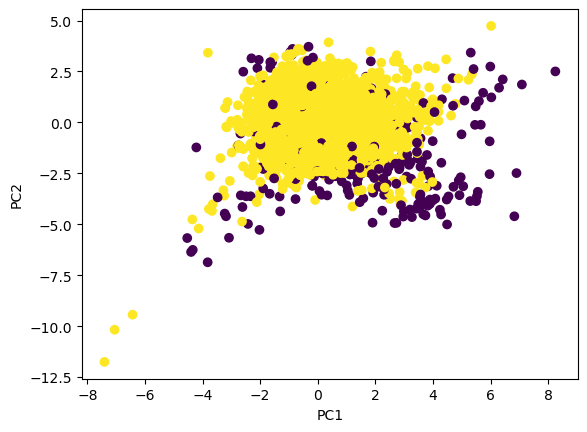

In [9]:
plt.scatter(pca_data[:,0],pca_data[:,1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [10]:
import numpy as np
n_outliers=np.sum(labels==-1)
n_normal=np.sum(labels==1)
print("Outliers count: ",n_outliers)
print("Normal count: ",n_normal)

Outliers count:  270
Normal count:  6646


In [14]:
#LOF
from sklearn.neighbors import LocalOutlierFactor
lof=LocalOutlierFactor(contamination=0.036)
labels=lof.fit_predict(X_scaled)

Text(0, 0.5, 'PC2')

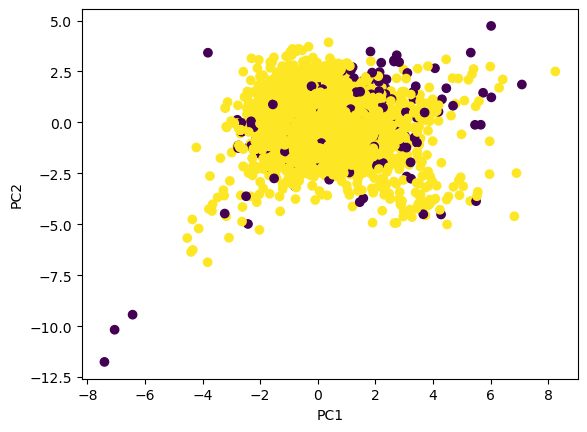

In [15]:
plt.scatter(pca_data[:,0],pca_data[:,1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [16]:
n_outliers=np.sum(labels==-1)
n_normal=np.sum(labels==1)
print("Outliers count: ",n_outliers)
print("Normal count: ",n_normal)

Outliers count:  249
Normal count:  6667
